# Постановка задачи


**Цель работы:** изучение основных способов визуализации табличных данных с помощью модулей `seaborn`, `plotly`, `altair`, `bokeh`.

**Краткое описание:** в лабораторной работе представлено 10 заданий на построение графиков разных видов. В каждом задании указано, каким видом графика стоит воспользоваться для визуализации данных. По каждому заданию необходимо построить график дважды: первый раз с помощью модуля `seaborn` (альтернативно можно `matplotlib` со стилями из `seaborn`), второй – с помощью `plotly`, `altair` или `bokeh` на выбор студента. Необязательно каждый раз для второго графика выбирать одну и ту же библиотеку, т.к. не все библиотеки располагают одинаковым набором графиков.

# Данные


По [ссылке](https://drive.google.com/drive/folders/1e0E4vQzaE9LBZgfzz0AzsyAXgtH0eMaP?usp=share_link) расположена таблица с информацией о песнях, исполненных на Евровидении с 2009 по 2023 год. Все задания лабораторной работы необходимо выполнять по этим данным. Данные в полном объеме можно найти [по ссылке](https://www.kaggle.com/datasets/diamondsnake/eurovision-song-contest-data).

##### **Формат данных**

```
year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
2023,Norway,Alessandra,Queen of Kings,English,Pop,Female,1,E Minor,110,36,64,23,10 dB,58,0,10,3,5
2023,Malta,The Busker,Dance (Our Own Party),English,Pop,Male,1,F Minor,103,78,70,82,6 dB,2,0,18,4,
...
```
##### **Описание полей**

- ```year``` – год;
- ```country``` – страна участника;
- ```artist_name``` – исполнитель;
- ```song_name``` – название песни;
- ```language``` – язык, на котором исполняется песня;
- ```style```	– жанр;
- ```gender``` – пол участника;
- ```main_singers``` – количество вокалистов;
- ```key```	– регистр (высота тона);
- ```BPM``` – скорость композиции в целом (количество четвертых нот в минуту);
- ```energy``` – энергичность композиции;
- ```danceability``` – танцевальность (насколько трек подходит для танцев);
- ```happiness``` – жизнерадостность;
- ```loudness``` – громкость;
- ```acousticness``` – акустичность;
- ```instrumentalness``` – инструментальность;
- ```liveness``` – живость;
- ```speechiness``` – насколько много текста;
- ```final_place``` – место в финале.

# Практические задания

>По каждому заданию должен быть сделан вывод. Также нужно обязательно добавлять подпись графика и осей.

In [1]:
import pandas as pd
import numpy as np
import nbformat
import matplotlib.pyplot as plt
import plotly.figure_factory as ff
import plotly.express as px
import altair as alt
import seaborn as sns
import pycountry
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

## Задание 1

Проведите предобработку числовых значений в датасете:
1. В столбцах `BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` замените отсутствующие значения и прочерки на 0.
2. В столбце `loudness` оставьте только число без единиц измерения.
3. Во всех перечисленных в пунктах 1 и 2 столбцах преобразуйте значения в тип данных `float`.

In [2]:
df = pd.read_csv('song_data.csv')

cols_to_fix = [
    'BPM', 'energy', 'danceability', 'happiness',
    'acousticness', 'instrumentalness', 'liveness', 'speechiness'
]
for col in cols_to_fix:
    df[col] = df[col].replace('-', '0').fillna('0')

df['loudness'] = df['loudness'].astype(str).str.replace(' dB', '', regex=False).replace('-', '0').fillna('0')

all_numeric_cols = cols_to_fix + ['loudness']
for col in all_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0).astype(float)


print(df[all_numeric_cols].info())

<class 'pandas.DataFrame'>
RangeIndex: 565 entries, 0 to 564
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   BPM               565 non-null    float64
 1   energy            565 non-null    float64
 2   danceability      565 non-null    float64
 3   happiness         565 non-null    float64
 4   acousticness      565 non-null    float64
 5   instrumentalness  565 non-null    float64
 6   liveness          565 non-null    float64
 7   speechiness       565 non-null    float64
 8   loudness          565 non-null    float64
dtypes: float64(9)
memory usage: 39.9 KB
None


## Задание 2

Покажите, какие характеристики музыки (`BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`) коррелируют между собой. Для визуализации используйте диаграмму `heatmap`.

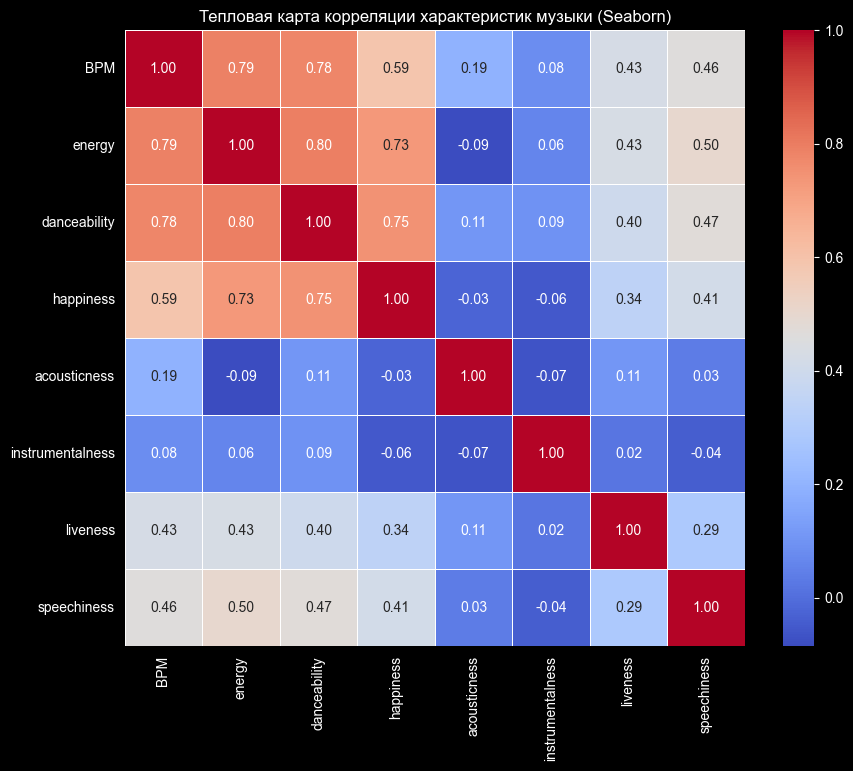

In [3]:
cols = ['BPM', 'energy', 'danceability', 'happiness', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']
corr_matrix = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Тепловая карта корреляции характеристик музыки (Seaborn)')
plt.show()
print()

fig = px.imshow(corr_matrix,
                text_auto='.2f',
                color_continuous_scale='RdBu_r',
                title='Тепловая карта корреляции характеристик музыки (Plotly)',
                labels=dict(color="Correlation"))
fig.show()

Вывод

Наиболее сильную связь можно увидеть между темпом и энергичностью, темпом и танцевальностью, танцевальностью и энергичностью, счастьем и танцевальностью, энергичностью и танцевальностью.

## Задание 3

Покажите на диаграмме разброса взаимосвязь между жизнерадостностью (`happiness`) и энергичностью (`energy`) композиции. Добавьте на диаграмму вспомогательные элементы для упрощения интерпретации визуализации:
- отметку средних значений
- выбросы



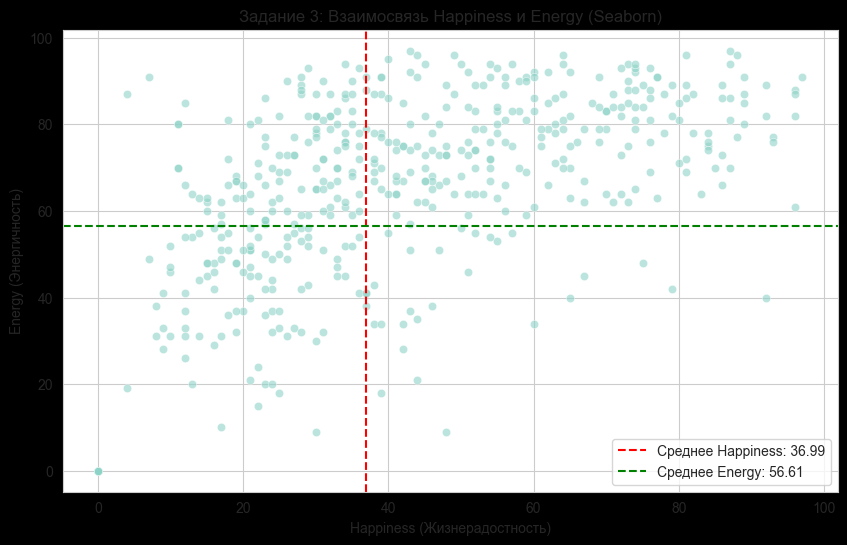

alt.LayerChart(...)

In [4]:
def get_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1 * IQR
    upper_bound = Q3 + 1 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

mean_h = df['happiness'].mean()
mean_e = df['energy'].mean()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.scatterplot(data=df, x='happiness', y='energy', alpha=0.6)

plt.axvline(mean_h, color='red', linestyle='--', label=f'Среднее Happiness: {mean_h:.2f}')
plt.axhline(mean_e, color='green', linestyle='--', label=f'Среднее Energy: {mean_e:.2f}')

plt.title('Задание 3: Взаимосвязь Happiness и Energy (Seaborn)')
plt.xlabel('Happiness (Жизнерадостность)')
plt.ylabel('Energy (Энергичность)')
plt.legend()
plt.show()

df['is_outlier'] = get_outliers(df, 'happiness') | get_outliers(df, 'energy')
df['status'] = df['is_outlier'].map({True: 'Выброс', False: 'Норма'})

scatter = alt.Chart(df).mark_circle(size=60).encode(
    x=alt.X('happiness:Q', title='Happiness (Жизнерадостность)'),
    y=alt.Y('energy:Q', title='Energy (Энергичность)'),
    color=alt.Color('status:N',
                    scale=alt.Scale(domain=['Норма', 'Выброс'], range=['#4c78a8', '#e15759']),
                    legend=alt.Legend(title="Статус точки")),
    tooltip=['artist_name', 'song_name', 'happiness', 'energy']
).properties(
    title='Взаимосвязь Happiness и Energy с выделением выбросов (Altair)',
    width=600,
    height=400
)

line_h = alt.Chart(pd.DataFrame({'x': [mean_h]})).mark_rule(color='red', strokeDash=[5, 5]).encode(x='x:Q')
line_e = alt.Chart(pd.DataFrame({'y': [mean_e]})).mark_rule(color='green', strokeDash=[5, 5]).encode(y='y:Q')

final_chart = (scatter + line_h + line_e).interactive()

final_chart.display()

Вывод

Наличие положительной корреляции: наблюдается умеренная прямая зависимость — с ростом жизнерадостности (happiness) растет и энергичность (energy).

## Задание 4

Покажите на горизонтальной столбчатой диаграмме распределение количества треков по жанрам. Отсортируйте диаграмму по убыванию количества композиций в жанре. Выделите контрастным цветом жанр, в котором больше всего песен.

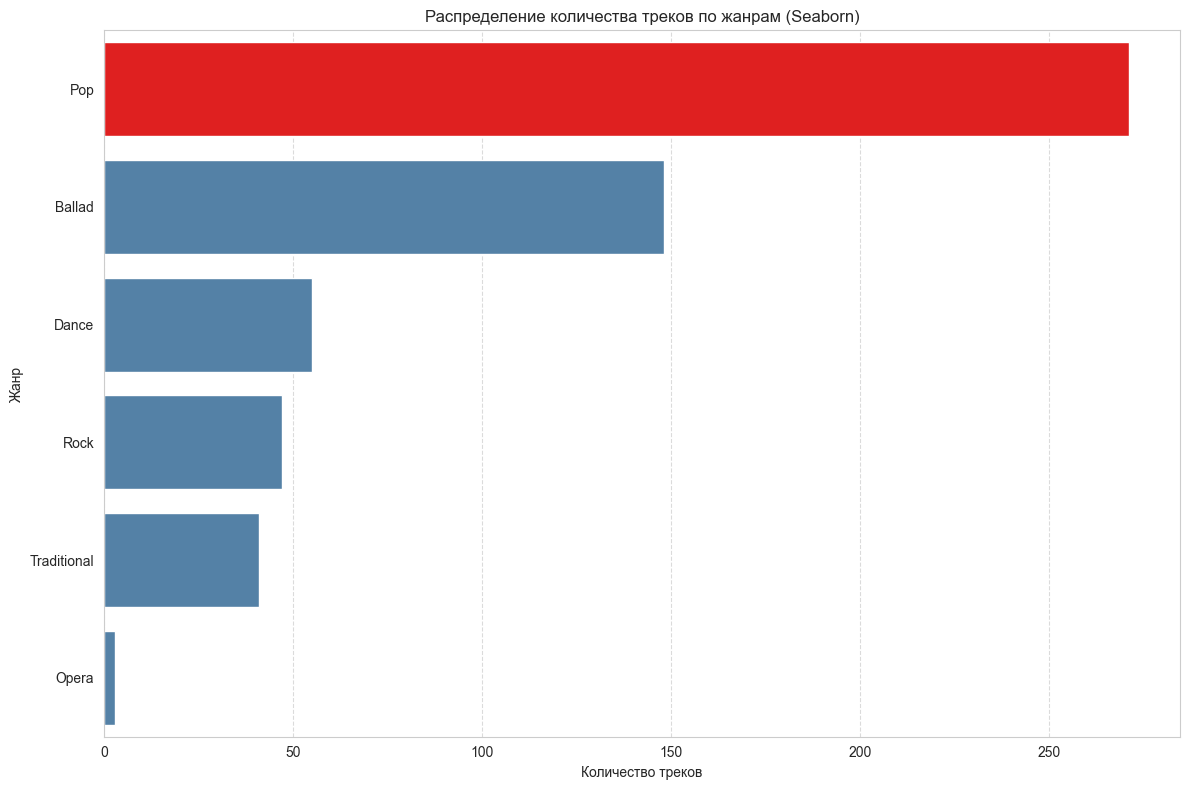

In [5]:
genre_counts = df['style'].value_counts().reset_index()
genre_counts.columns = ['style', 'count']

plt.figure(figsize=(12, 8))
colors = ['red' if i == 0 else 'steelblue' for i in range(len(genre_counts))]
ax = sns.barplot(data=genre_counts, x='count', y='style', palette=colors, hue='style')

plt.title('Распределение количества треков по жанрам (Seaborn)')
plt.xlabel('Количество треков')
plt.ylabel('Жанр')
plt.grid(axis='x', linestyle='--', alpha=0.7)
if ax.legend_: ax.legend_.remove()
plt.tight_layout()
plt.show()


fig = px.bar(genre_counts,
             x='count',
             y='style',
             orientation='h',
             title='Распределение количества треков по жанрам (Plotly)',
             labels={'count': 'Количество треков', 'style': 'Жанр'},
             color='count',
             color_continuous_scale=['steelblue', 'red'])

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

Вывод

Больше всего треков в жанре поп, баллады, танцевальный меньше всего оперы.

## Задание 5

Покажите на круговой диаграмме страны, участники из которых побеждали чаще других, и в каких годах они выигрывали. Диаграмма должна быть одна.

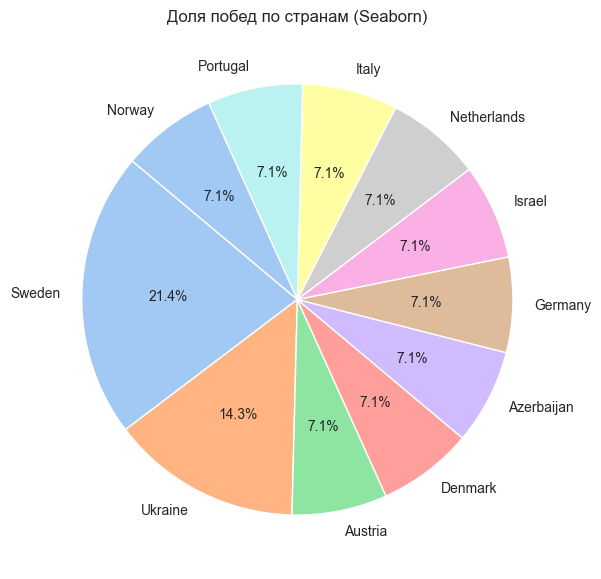

In [6]:
winners = df[df['final_place'] == 1].copy()
winner_stats = winners.groupby('country').agg(
    win_count=('year', 'count'),
    years=('year', lambda x: ', '.join(map(str, sorted(x))))
).reset_index().sort_values(by='win_count', ascending=False)

plt.figure(figsize=(10, 7))
plt.pie(winner_stats['win_count'],
        labels=winner_stats['country'],
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))
plt.title('Доля побед по странам (Seaborn)')
plt.show()

fig = px.pie(winner_stats,
             values='win_count',
             names='country',
             hover_data=['years'],
             title='Частота побед и годы (Plotly)')
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

Вывод

Чаще всего побеждали участники из Швеции (2012, 2015, 2023), Украины (2016, 2022). Все остальные, указанные на диаграмме, по одному разу.

## Задание 6

На вертикальной столбчатой диаграмме с группировкой покажите количество мужчин и женщин среди участников в каждом году, представленном в датасете.

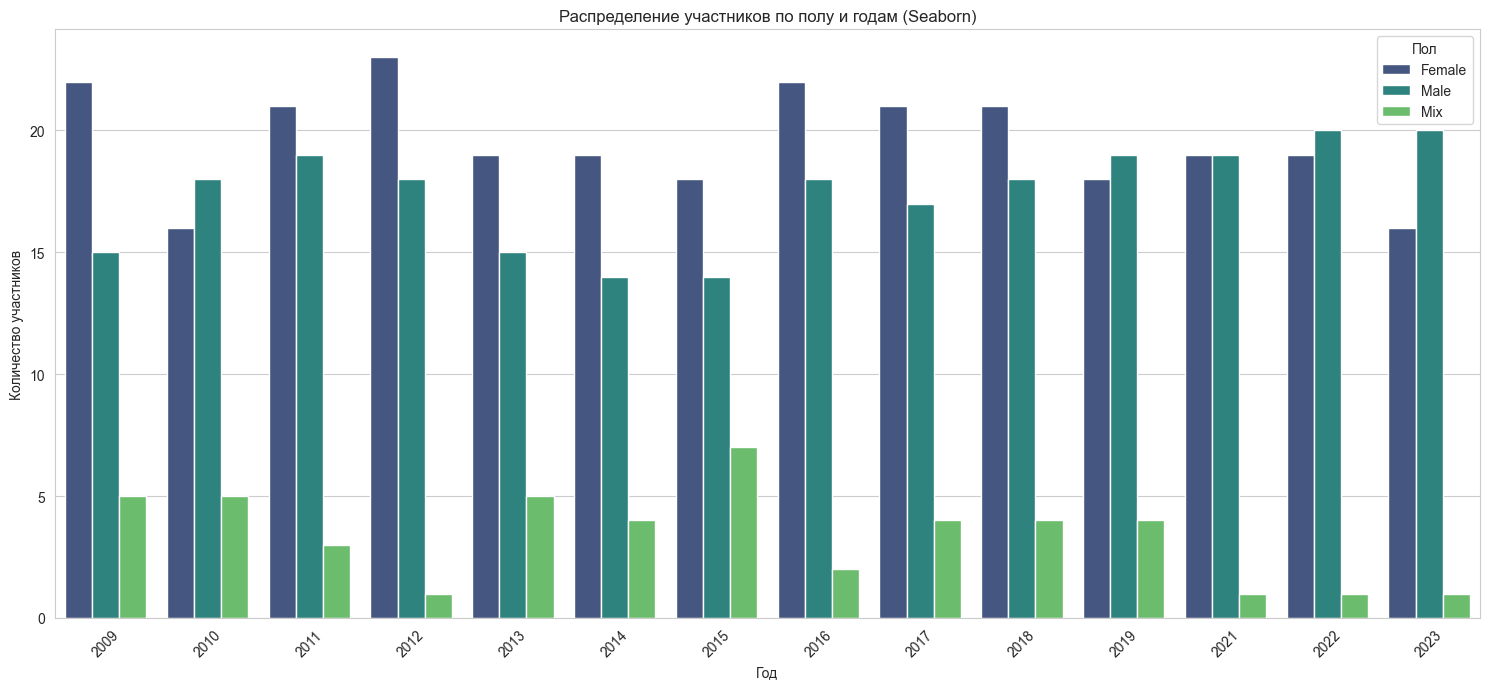

In [7]:
gender_counts = df.groupby(['year', 'gender']).size().reset_index(name='count')

plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")

sns.barplot(data=gender_counts, x='year', y='count', hue='gender', palette='viridis')

plt.title('Распределение участников по полу и годам (Seaborn)')
plt.xlabel('Год')
plt.ylabel('Количество участников')
plt.xticks(rotation=45)
plt.legend(title='Пол')
plt.tight_layout()
plt.show()

fig = px.bar(gender_counts,
             x='year',
             y='count',
             color='gender',
             barmode='group',
             title='Распределение участников по полу и годам (Plotly)',
             labels={'count': 'Количество', 'year': 'Год', 'gender': 'Пол'})

fig.update_layout(xaxis_tickangle=-45)
fig.show()

Вывод

До 2019 года почти всегда (кроме 2010г) больше выступало женских исполнителей, после - больше мужчин (в 2021 - одинаково).

## Задание 7

Постройте график плотности распределения данных в столбце `danceability` (танцевальность), сгруппированных по категориям жанрам.

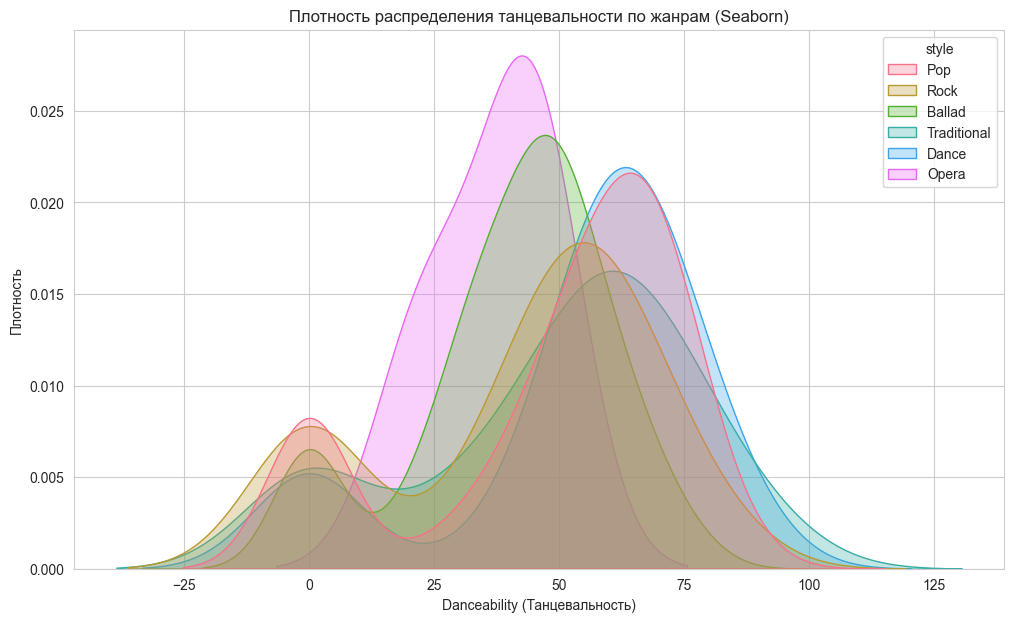

In [8]:
df['danceability'] = pd.to_numeric(df['danceability'], errors='coerce')
df_clean = df.dropna(subset=['danceability'])

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.kdeplot(data=df_clean, x='danceability', hue='style', fill=True, common_norm=False, palette='husl', alpha=0.3)

plt.title('Плотность распределения танцевальности по жанрам (Seaborn)')
plt.xlabel('Danceability (Танцевальность)')
plt.ylabel('Плотность')
plt.show()

genres = df_clean['style'].unique()
hist_data = [df_clean[df_clean['style'] == g]['danceability'] for g in genres]

fig = ff.create_distplot(hist_data, genres, show_hist=False, show_rug=False)
fig.update_layout(title='Плотность распределения по жанрам (Plotly)')
fig.show()

Вывод

Наибольшая плотность у оперы в отметке чуть выше 40 по пункту танцевальности. Также высокая в значениях около 50 у баллад, у поп и танцевальной (около 65).

## Задание 8

Покажите на ящиковой диаграмме взяимосвязь позиции в финальном рейтинге со страной. Итоги каких стран похожи между собой? Отсортируйте или сгруппируйте ящики так, чтобы упростить интерпретацию графика.

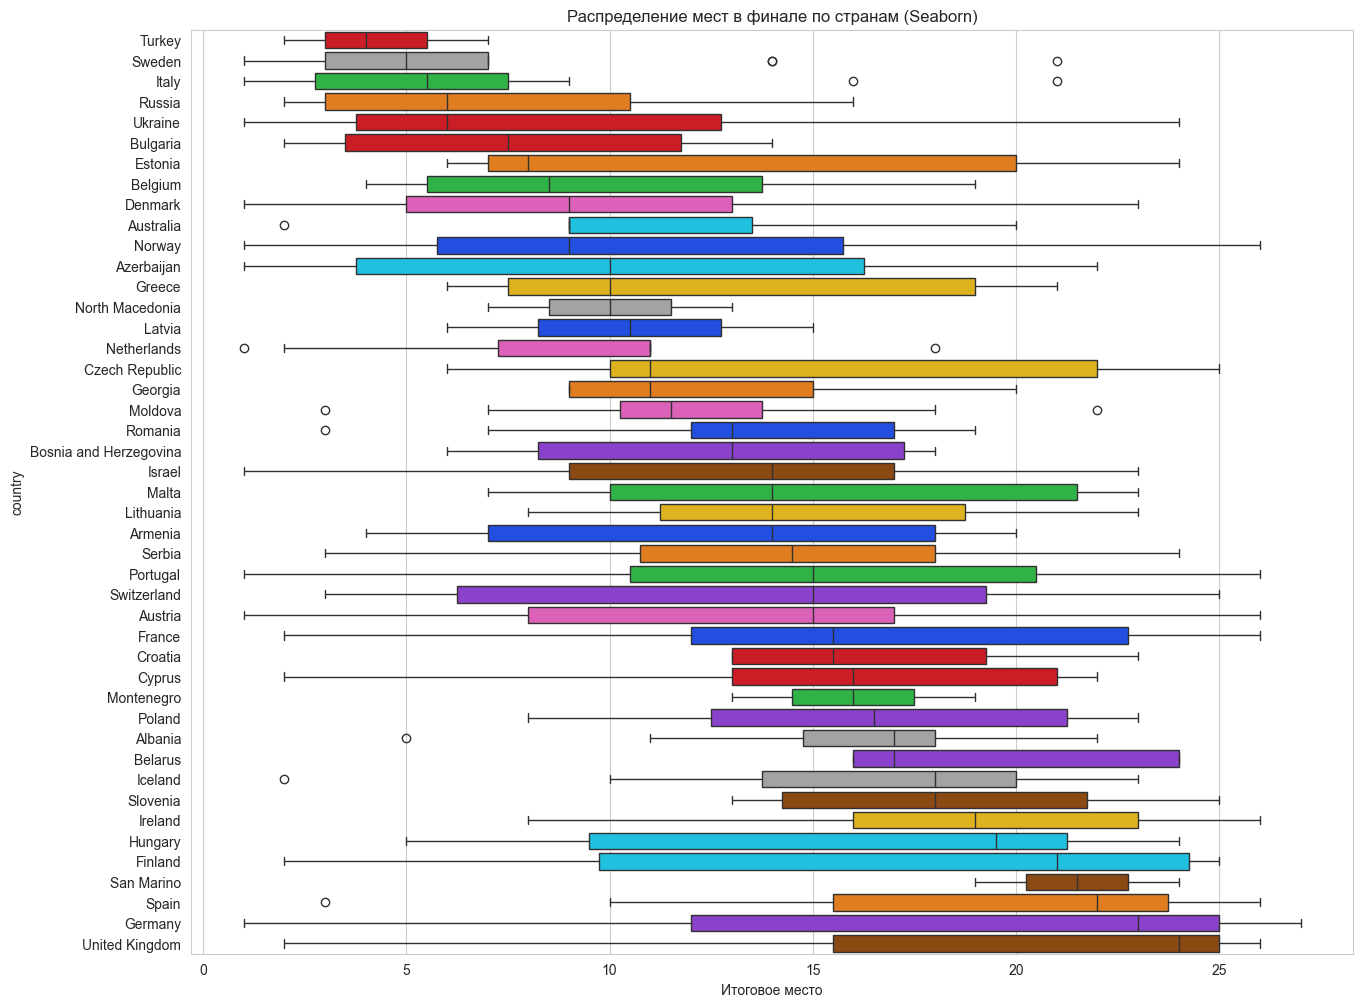

In [9]:
df_final = df.dropna(subset=['final_place'])
order = df_final.groupby('country')['final_place'].median().sort_values().index

plt.figure(figsize=(15, 12))
sns.boxplot(
    data=df_final,
    y='country',
    x='final_place',
    order=order,
    palette='bright',
    hue='country',
    legend=False
)
plt.title('Распределение мест в финале по странам (Seaborn)')
plt.xlabel('Итоговое место')
plt.show()


fig = px.box(df_final, y="country", x="final_place",
             category_orders={"country": list(order)},
             title="Взаимосвязь позиции в финале со страной (Plotly)")
fig.update_layout(height=1000)
fig.show()

Вывод

Похожие результаты у Швеции и Италии, Германии и Великобритании.



## Задание 9

Покажите на карте количество раз, когда каждая страна датасета проходила в финал.

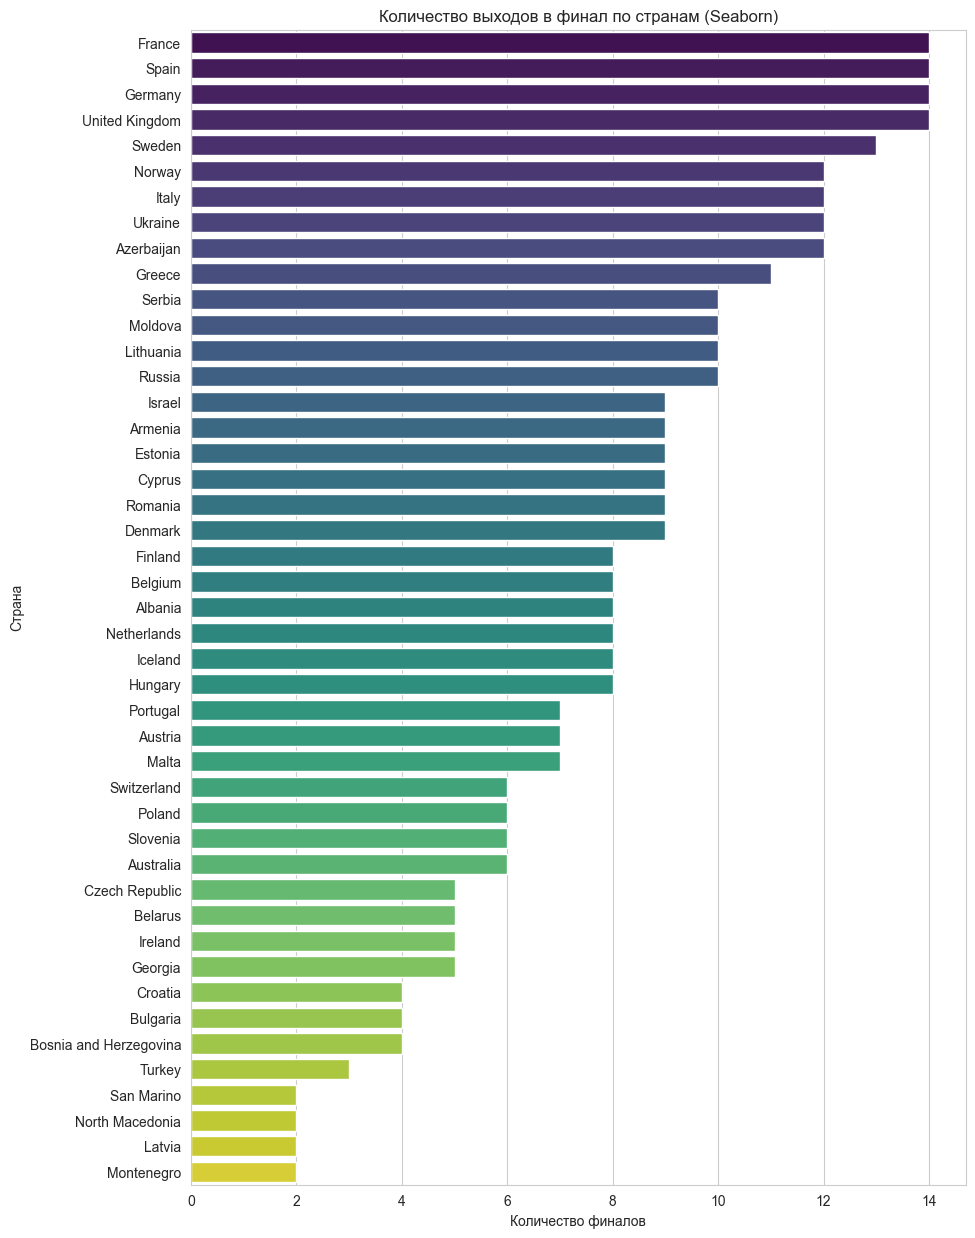

In [10]:
finalists = df.dropna(subset=['final_place'])
final_counts = finalists['country'].value_counts().reset_index()
final_counts.columns = ['country', 'count']

plt.figure(figsize=(10, 15))
ax = sns.barplot(
    data=final_counts.sort_values('count', ascending=False),
    x='count',
    y='country',
    palette='viridis',
    hue='country'
)
if ax.legend_: ax.legend_.remove()

plt.title('Количество выходов в финал по странам (Seaborn)')
plt.xlabel('Количество финалов')
plt.ylabel('Страна')
plt.show()

def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

final_counts = df.dropna(subset=['final_place'])['country'].value_counts().reset_index()
final_counts.columns = ['country', 'count']

final_counts['iso_alpha'] = final_counts['country'].apply(get_iso3)

fig = px.choropleth(
    final_counts,
    locations="iso_alpha",
    locationmode="ISO-3",
    color="count",
    hover_name="country",
    color_continuous_scale='Viridis',
    title='География выходов в финал (Стандарт ISO-3)',
    scope='europe'
)

fig.show()

Вывод

Больше всего количество выходов в финал у Франции, Испании, Германии, Великобритании.

## Задание 10

Покажите на диаграмме вида `treemap`, сколько раз каждая страна входила в топ-3 победителей.

*В `seaborn` нет такого типа графика, с помощью этого модуля строить график не нужно.*

In [11]:
df['final_place'] = pd.to_numeric(df['final_place'], errors='coerce')
top_3_winners = df[df['final_place'].isin([1, 2, 3])]

top_3_counts = top_3_winners['country'].value_counts().reset_index()
top_3_counts.columns = ['country', 'count']

fig = px.treemap(top_3_counts,
                 path=['country'],
                 values='count',
                 color='count',
                 color_continuous_scale='Viridis',
                 title='Количество попаданий в топ-3 (2009–2023)')

fig.update_traces(textinfo="label+value")
fig.show()

Вывод

Чаще всего в топ-3 входили Швеция, Италия, Россия.

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения 10 заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой построение визуализации по данным из лабораторной работы, по сложности аналогичной тем, что требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. Покажите на ящиковой диаграмме распределение танцевальности для каждого жанра. Выполните с помощью `seaborn`.
2. На круговой диаграмме покажите исполнителей, которые участвовали больше одного раза и какие места они занимали. Выполните с помощью `plotly`.
3. Покажите на диаграмме вида `treemap`, сколько раз каждая страна проходила в финал. Выполните с помощью `plotly`.

# Дополнительные материалы

1. seaborn: statistical data visualization [Электронный ресурс]. URL: https://seaborn.pydata.org/ (дата обращения: 01.04.2024).
2. Plotly Open Source Graphing Libraries [Электронный ресурс]. URL: https://plotly.com/graphing-libraries/ (дата обращения: 01.04.2024).
3. Vega-Altair: Declarative Visualization in Python [Электронный ресурс]. URL: https://altair-viz.github.io/index.html (дата обращения: 01.04.2024).